# Topic distributions as interpretable features — experimental pipelinePoster: *Topic Distributions as Interpretable Features for Text Classification:Measuring the Accuracy Cost of Transparency*Running this notebook end to end produces everything the poster needs:| Output | Poster slot ||---|---|| `results_table.csv` and the printed table | Table 1, section 7 || `fig1.png` | Plot A, section 7 || `fig2.png` | Plot B, section 7 || printed findings block | section 8 bullet points || printed topic explanations | sections 8 and 9 |Runtime is a few minutes on a laptop CPU. No GPU is required.

## 1. Environment

In [1]:
# Run once. On Colab the first line is enough.
!pip install -q scikit-learn nltk matplotlib pandas
# Optional, only needed for the embedding baseline in section 6:
# !pip install -q sentence-transformers

In [2]:
import numpy as np, pandas as pd, matplotlib, nltk
import matplotlib.pyplot as plt

from nltk.corpus import reuters
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

In [3]:


SEED      = 42
N_TOPICS  = [10, 20, 40]          # values of K compared on the poster
R8        = ["earn", "acq", "crude", "trade", "money-fx", "interest", "ship", "grain"]

# poster-friendly figure defaults: large fonts, vector-quality raster export
plt.rcParams.update({
    "font.size": 13, "axes.labelsize": 14, "axes.titlesize": 14,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 13,
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, ORANGE, TEAL, GREY = "#2B6CB0", "#C05621", "#2C7A7B", "#A0AEC0"
np.random.seed(SEED)

## 2. DatasetReuters-21578, R8 subset: the eight largest categories, single-label documentsonly, standard ModApte split. The corpus ships with NLTK, so no manual downloadis needed.

In [4]:
import os
import joblib
import shutil

# Mount Google Drive only when running in Colab.
try:
    from google.colab import drive
except ImportError:
    pass
else:
    drive.mount('/content/drive')

def save_artifacts(model_path, plots_path, lda_model, lr_model, fig1_name="fig1.png", fig2_name="fig2.png"):
    """
    Saves the LDA model, Logistic Regression model, and plots to specified paths.
    """
    print(f"Saving artifacts to MODEL_PATH: {model_path} and PLOTS_PATH: {plots_path}")
    os.makedirs(model_path, exist_ok=True)
    os.makedirs(plots_path, exist_ok=True)

    # Save models
    joblib.dump(lda_model, os.path.join(model_path, 'lda_model.joblib'))
    joblib.dump(lr_model, os.path.join(model_path, 'logistic_regression_model.joblib'))
    print("Models saved.")

    # Move plots
    if os.path.exists(fig1_name):
        shutil.move(fig1_name, os.path.join(plots_path, fig1_name))
        print(f"{fig1_name} moved to {plots_path}")
    else:
        print(f"Warning: {fig1_name} not found in current directory.")
    if os.path.exists(fig2_name):
        shutil.move(fig2_name, os.path.join(plots_path, fig2_name))
        print(f"{fig2_name} moved to {plots_path}")
    else:
        print(f"Warning: {fig2_name} not found in current directory.")

    print("Artifact saving complete.")

Mounted at /content/drive


In [5]:
# Get the current Unix timestamp (seconds since the epoch)
unix_timestamp = time.time()
print(f"Unix Timestamp (seconds since epoch): {unix_timestamp}")

# Get a human-readable formatted timestamp
# You can customize the format string as needed
formatted_timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(unix_timestamp))
print(f"Formatted Timestamp: {formatted_timestamp}")


Unix Timestamp (seconds since epoch): 1790525287.5151951
Formatted Timestamp: 2026-09-27 16:08:07


In [6]:
MODEL_PATH = '/content/drive/MyDrive/Dataset/nlp'
PLOTS_PATH = f'/content/drive/MyDrive/Dataset/nlp/plot{formatted_timestamp}'

In [7]:
nltk.download("reuters", quiet=True)

def load_split(prefix):
    texts, labels = [], []
    for fid in reuters.fileids():
        if not fid.startswith(prefix):
            continue
        cats = reuters.categories(fid)
        if len(cats) == 1 and cats[0] in R8:      # single-label R8 documents
            texts.append(reuters.raw(fid))
            labels.append(cats[0])
    return texts, np.array(labels)

X_train_txt, y_train = load_split("training/")
X_test_txt,  y_test  = load_split("test/")

print(f"train: {len(X_train_txt)}   test: {len(X_test_txt)}   classes: {len(R8)}")
print(pd.Series(y_test).value_counts().to_string())

train: 5501   test: 2190   classes: 8
earn        1083
acq          696
crude        121
money-fx      87
interest      81
trade         76
ship          36
grain         10


## 3. PreprocessingStopword removal, alphabetic tokens of at least three characters, and documentfrequency pruning. The same raw text feeds both representations, so the onlydifference between the two systems is the feature space.

In [8]:
count_vec = CountVectorizer(stop_words="english", max_df=0.5, min_df=5,
                            token_pattern=r"(?u)\b[a-zA-Z]{3,}\b")
C_train = count_vec.fit_transform(X_train_txt)
C_test  = count_vec.transform(X_test_txt)
vocab   = count_vec.get_feature_names_out()
print("bag-of-words vocabulary:", len(vocab))

bag-of-words vocabulary: 4979


## 4. Scoring helperEvery configuration is scored by the same function, so the numbers in Table 1are comparable by construction.

In [9]:
results = []          # one row per model, later written to results_table.csv

def evaluate(name, dims, X_tr, X_te, C=10):
    clf  = LogisticRegression(max_iter=2000, C=C)
    clf.fit(X_tr, y_train)
    pred = clf.predict(X_te)
    row = {"model": name, "dims": dims,
           "accuracy": accuracy_score(y_test, pred),
           "macro_f1": f1_score(y_test, pred, average="macro"),
           "weighted_f1": f1_score(y_test, pred, average="weighted"),
           "min_class_f1": f1_score(y_test, pred, average=None,
                                    labels=sorted(set(y_test))).min()}
    results.append(row)
    print(f"{name:<22} acc={row['accuracy']:.4f}  macroF1={row['macro_f1']:.4f}")
    return clf, pred

## 5. Topic featuresLDA is fitted on the training split only. Test proportions are inferred with thefitted model, so no test information enters estimation.

In [10]:
lda_store = {}

for k in N_TOPICS:
    lda = LatentDirichletAllocation(n_components=k, learning_method="batch",
                                    max_iter=30, random_state=SEED, n_jobs=-1)
    T_train = lda.fit_transform(C_train)     # document-topic matrix
    T_test  = lda.transform(C_test)
    clf, pred = evaluate(f"LDA K={k}", k, T_train, T_test)
    lda_store[k] = (lda, clf, T_test, pred)

LDA K=10               acc=0.9114  macroF1=0.6411
LDA K=20               acc=0.9233  macroF1=0.6970
LDA K=40               acc=0.9384  macroF1=0.7385


## 6. BaselinesTF-IDF is the lexical reference point. The embedding block is optional; skip itif `sentence-transformers` is not installed, and leave that row of Table 1 empty.

In [11]:
tfidf   = TfidfVectorizer(stop_words="english", sublinear_tf=True, min_df=2)
F_train = tfidf.fit_transform(X_train_txt)
F_test  = tfidf.transform(X_test_txt)
evaluate("TF-IDF", F_train.shape[1], F_train, F_test)

TF-IDF                 acc=0.9680  macroF1=0.9154


(LogisticRegression(C=10, max_iter=2000),
 array(['trade', 'grain', 'ship', ..., 'crude', 'acq', 'ship'], dtype='<U8'))

In [12]:
# Optional dense baseline
try:
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer("all-MiniLM-L6-v2")
    E_train = enc.encode(X_train_txt, batch_size=64, show_progress_bar=True)
    E_test  = enc.encode(X_test_txt,  batch_size=64, show_progress_bar=True)
    evaluate("MiniLM embeddings", E_train.shape[1], E_train, E_test)
except Exception as e:
    print("embedding baseline skipped:", type(e).__name__)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

MiniLM embeddings      acc=0.9644  macroF1=0.9272


## 7. Table 1The printed table is what goes into the poster. Copy the four columns(model, dims, accuracy, macro-F1) into the LaTeX table in section 7, replacingeach `\tbd`.

In [13]:
df = pd.DataFrame(results).round(4)
df.to_csv("results_table.csv", index=False)
display(df)

print("\nLaTeX rows for the poster:")
for _, r in df.iterrows():
    print(f"{r['model']} & {int(r['dims']):,} & {r['accuracy']:.4f} & {r['macro_f1']:.4f} \\\\")

,model,dims,accuracy,macro_f1,weighted_f1,min_class_f1
0,LDA K=10,10,0.9114,0.6411,0.9067,0.0000
1,LDA K=20,20,0.9233,0.6970,0.9195,0.3137
2,LDA K=40,40,0.9384,0.7385,0.9364,0.1250
3,TF-IDF,11639,0.9680,0.9154,0.9676,0.8398
4,MiniLM embeddings,384,0.9644,0.9272,0.9640,0.8308



LaTeX rows for the poster:
LDA K=10 & 10 & 0.9114 & 0.6411 \\
LDA K=20 & 20 & 0.9233 & 0.6970 \\
LDA K=40 & 40 & 0.9384 & 0.7385 \\
TF-IDF & 11,639 & 0.9680 & 0.9154 \\
MiniLM embeddings & 384 & 0.9644 & 0.9272 \\


## 8. Plot A — accuracy against macro-F1Saved as `fig1.png` at 300 dpi. In the poster, replace the Plot A placeholder by```latex\includegraphics[width=\textwidth]{fig1.png}```

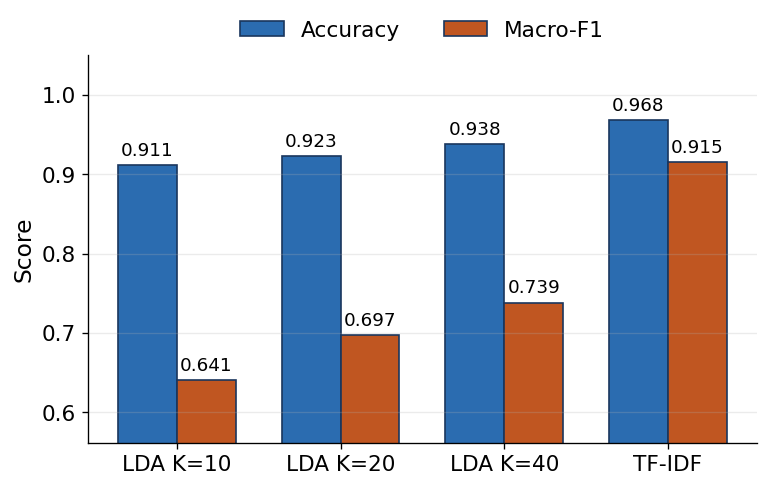

In [14]:
d = df[df.model != "MiniLM embeddings"]           # keep the poster comparison readable
x = np.arange(len(d)); w = 0.36

fig, ax = plt.subplots(figsize=(7.2, 4.2))
b1 = ax.bar(x - w/2, d.accuracy,  w, label="Accuracy", color=BLUE,   edgecolor="#1A365D")
b2 = ax.bar(x + w/2, d.macro_f1,  w, label="Macro-F1", color=ORANGE, edgecolor="#1A365D")
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
            f"{b.get_height():.3f}", ha="center", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(d.model)
ax.set_ylim(min(d.macro_f1.min(), d.accuracy.min()) - 0.08, 1.05)
ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.14))
fig.savefig("fig1.png"); plt.show()

## 9. Plot B — per-category F1 against class sizeSaved as `fig2.png`. This is the figure that answers RQ2.

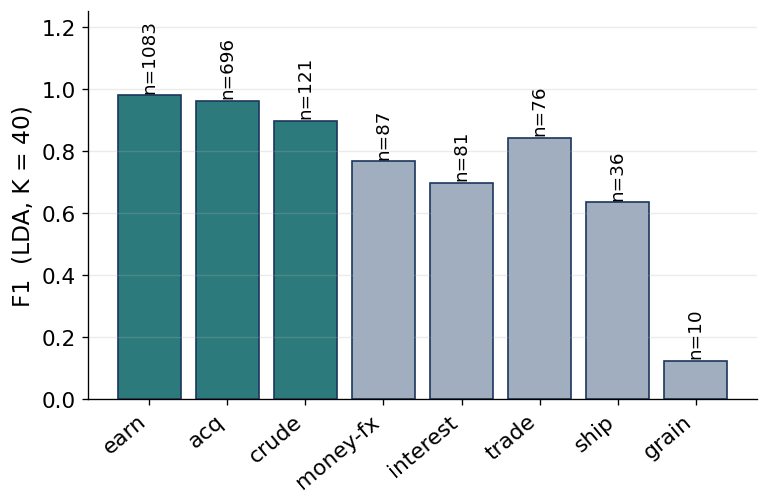

              precision    recall  f1-score   support

         acq      0.956     0.967     0.961       696
       crude      0.922     0.876     0.898       121
        earn      0.979     0.982     0.980      1083
       grain      0.167     0.100     0.125        10
    interest      0.902     0.568     0.697        81
    money-fx      0.685     0.874     0.768        87
        ship      0.741     0.556     0.635        36
       trade      0.778     0.921     0.843        76

    accuracy                          0.938      2190
   macro avg      0.766     0.730     0.738      2190
weighted avg      0.939     0.938     0.936      2190



In [15]:
best_k = max(N_TOPICS, key=lambda k: dict(zip([r['model'] for r in results],
                                              [r['macro_f1'] for r in results]))[f"LDA K={k}"])
_, clf, T_test, pred = lda_store[best_k]

labels  = sorted(set(y_test))
f1c     = f1_score(y_test, pred, average=None, labels=labels)
support = [int((y_test == c).sum()) for c in labels]
order   = np.argsort(support)[::-1]
labels  = [labels[i] for i in order]; f1c = f1c[order]
support = [support[i] for i in order]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(labels, f1c, color=[TEAL if s >= 100 else GREY for s in support],
              edgecolor="#1A365D")
for b, s in zip(bars, support):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"n={s}",
            ha="center", fontsize=11, rotation=90)
ax.set_ylabel(f"F1  (LDA, K = {best_k})"); ax.set_ylim(0, 1.25)
ax.grid(axis="y", alpha=0.25); plt.xticks(rotation=40, ha="right")
fig.savefig("fig2.png"); plt.show()

print(classification_report(y_test, pred, digits=3))

In [16]:
print('\nSaving models and plots...')
# Retrieve the best LDA model and its corresponding Logistic Regression classifier
best_lda_model = lda_store[best_k][0]
best_lr_model = lda_store[best_k][1]

save_artifacts(MODEL_PATH, PLOTS_PATH, best_lda_model, best_lr_model, fig1_name="fig1.png", fig2_name="fig2.png")


Saving models and plots...
Saving artifacts to MODEL_PATH: /content/drive/MyDrive/Dataset/nlp and PLOTS_PATH: /content/drive/MyDrive/Dataset/nlp/plot2026-09-27 16:08:07
Models saved.
fig1.png moved to /content/drive/MyDrive/Dataset/nlp/plot2026-09-27 16:08:07
fig2.png moved to /content/drive/MyDrive/Dataset/nlp/plot2026-09-27 16:08:07
Artifact saving complete.


## 10. ExplanationsFor a linear model on topic proportions, the coefficients are the explanation:no surrogate is fitted. The global view names the topics each class relies on,and the local view decomposes one prediction into additive contributions$\phi_t = \beta_{c,t}\,\theta_{d,t}$.

In [17]:
lda, clf, T_test, pred = lda_store[best_k]

def topic_words(t, n=8):
    return ", ".join(vocab[i] for i in lda.components_[t].argsort()[::-1][:n])

print(f"=== Global: top-2 topics per class (K={best_k}) ===")
for ci, cls in enumerate(clf.classes_):
    for t in clf.coef_[ci].argsort()[::-1][:2]:
        print(f"{cls:<10} topic {t:>2} (w={clf.coef_[ci][t]:+.2f}): {topic_words(t)}")

i  = 0                                   # any test document
ci = list(clf.classes_).index(pred[i])
contrib = clf.coef_[ci] * T_test[i]
print(f"\n=== Local: document {i} (true={y_test[i]}, pred={pred[i]}) ===")
for t in contrib.argsort()[::-1][:3]:
    print(f"topic {t:>2}  share={T_test[i][t]:.2f}  contribution={contrib[t]:+.2f}  |  {topic_words(t, 6)}")

=== Global: top-2 topics per class (K=40) ===
acq        topic 35 (w=+9.20): corp, company, dlrs, unit, mln, acquisition, agreement, sale
acq        topic 27 (w=+8.15): shares, pct, stake, stock, group, common, company, investment
crude      topic 37 (w=+12.84): oil, gas, energy, petroleum, exploration, tax, prices, pct
crude      topic  3 (w=+11.71): oil, opec, bpd, prices, mln, saudi, crude, output
earn       topic 19 (w=+8.98): cts, net, mln, loss, shr, revs, profit, qtr
earn       topic 39 (w=+8.65): dlrs, year, quarter, company, earnings, mln, share, expects
grain      topic 38 (w=+9.46): grain, department, certificates, agriculture, certificate, government, land, program
grain      topic 32 (w=+3.20): savings, national, federal, association, futures, illinois, home, continental
interest   topic  5 (w=+9.82): pct, bank, rate, rates, market, banks, money, stg
interest   topic 16 (w=+4.71): purolator, hutton, fairchild, courier, emery, offer, fujitsu, corp
money-fx   topic 34 (w=+8.

## 11. Findings blockThe printed lines map one to one onto the bullet points in section 8 of theposter. Paste the numbers into the bracketed slots.

In [18]:
best  = df[df.model == f"LDA K={best_k}"].iloc[0]
tfidf_row = df[df.model == "TF-IDF"].iloc[0]

print(f"best topic model : acc {best.accuracy:.4f}  macro-F1 {best.macro_f1:.4f}  (K={best_k})")
print(f"lexical baseline : acc {tfidf_row.accuracy:.4f}  macro-F1 {tfidf_row.macro_f1:.4f}")
print(f"accuracy gap     : {(tfidf_row.accuracy - best.accuracy)*100:.2f} points")
print(f"macro-F1 gap     : {(tfidf_row.macro_f1 - best.macro_f1)*100:.2f} points")
print(f"weakest category : {labels[int(np.argmin(f1c))]}  F1 {f1c.min():.3f} "
      f"at n={support[int(np.argmin(f1c))]}")
print(f"K trend          : " + ", ".join(
      f"K={k}: {df[df.model==f'LDA K={k}'].iloc[0].accuracy:.4f}" for k in N_TOPICS))

best topic model : acc 0.9384  macro-F1 0.7385  (K=40)
lexical baseline : acc 0.9680  macro-F1 0.9154
accuracy gap     : 2.96 points
macro-F1 gap     : 17.69 points
weakest category : grain  F1 0.125 at n=10
K trend          : K=10: 0.9114, K=20: 0.9233, K=40: 0.9384
